## Linear and Logistic Regression

Project focused in working with applied examples and algorithms.

a) Use Linear Regression to model one toy problem:

- Problem: Predict Co2 emission based on Engine Size


In [2]:
!pip install scikit-learn
!pip install numpy
!pip install matplotlib
!pip install pandas

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import linear_model
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder


df = pd.read_csv("FuelConsumptionCo2.csv")

print(df.head())

   MODELYEAR   MAKE       MODEL VEHICLECLASS  ENGINESIZE  CYLINDERS  \
0       2014  ACURA         ILX      COMPACT         2.0          4   
1       2014  ACURA         ILX      COMPACT         2.4          4   
2       2014  ACURA  ILX HYBRID      COMPACT         1.5          4   
3       2014  ACURA     MDX 4WD  SUV - SMALL         3.5          6   
4       2014  ACURA     RDX AWD  SUV - SMALL         3.5          6   

  TRANSMISSION FUELTYPE  FUELCONSUMPTION_CITY  FUELCONSUMPTION_HWY  \
0          AS5        Z                   9.9                  6.7   
1           M6        Z                  11.2                  7.7   
2          AV7        Z                   6.0                  5.8   
3          AS6        Z                  12.7                  9.1   
4          AS6        Z                  12.1                  8.7   

   FUELCONSUMPTION_COMB  FUELCONSUMPTION_COMB_MPG  CO2EMISSIONS  
0                   8.5                        33           196  
1                   

In [5]:
motors = df[['ENGINESIZE']]
co2 = df[['CO2EMISSIONS']]

print(motors.head())
print(co2.head())

   ENGINESIZE
0         2.0
1         2.4
2         1.5
3         3.5
4         3.5
   CO2EMISSIONS
0           196
1           221
2           136
3           255
4           244


In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(motors, co2, test_size=0.2, random_state=42)

print(f"X train: \n {X_train}")
print(f"X test: \n {X_test}")
print(X_train.shape)
print(X_test.shape)

X train: 
       ENGINESIZE
333          1.4
106          4.4
585          3.0
55           3.0
213          5.3
...          ...
330          3.6
466          2.4
121          4.4
1044         1.8
860          5.6

[853 rows x 1 columns]
X test: 
      ENGINESIZE
732         4.7
657         3.5
168         3.6
86          3.0
411         2.0
..          ...
963         2.0
294         2.4
275         2.4
903         3.0
941         8.4

[214 rows x 1 columns]
(853, 1)
(214, 1)


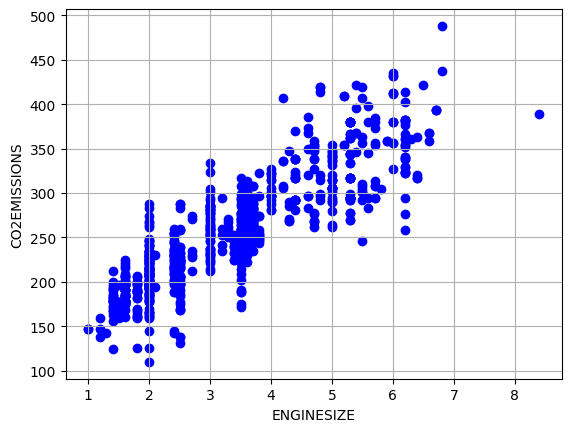

In [7]:
plt.scatter(X_train, Y_train, color='blue')
plt.xlabel('ENGINESIZE')
plt.ylabel('CO2EMISSIONS')
plt.grid()
plt.show()

In [8]:
model = linear_model.LinearRegression()
model.fit(X_train, Y_train)

print(f"Intercept: {model.intercept_}")
print(f"Coefficient: {model.coef_}")

Intercept: [126.28970217]
Coefficient: [[38.99297872]]


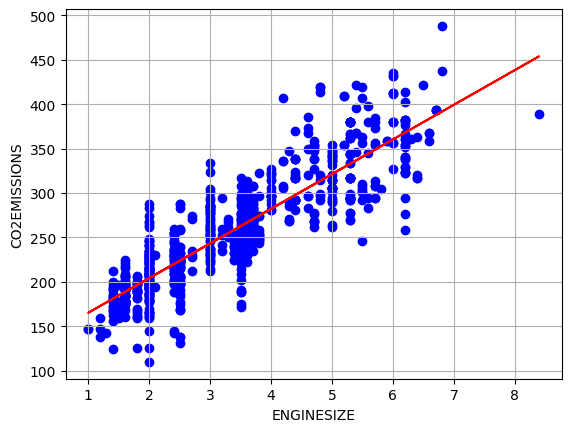

In [9]:
plt.scatter(X_train, Y_train, color='blue')
plt.plot(X_train, model.coef_[0][0] * X_train + model.intercept_[0], 'red')
plt.xlabel('ENGINESIZE')
plt.ylabel('CO2EMISSIONS')
plt.grid()
plt.show()

Predict: 
 [[309.55670218]
 [262.76512771]
 [266.66442558]
 [243.26863835]
 [204.27565962]
 [243.26863835]
 [266.66442558]
 [282.26161707]
 [321.2545958 ]
 [266.66442558]
 [266.66442558]
 [387.54265963]
 [251.06723409]
 [262.76512771]
 [266.66442558]
 [262.76512771]
 [188.67846813]
 [266.66442558]
 [188.67846813]
 [332.95248941]
 [321.2545958 ]
 [196.47706388]
 [251.06723409]
 [270.56372345]
 [243.26863835]
 [196.47706388]
 [204.27565962]
 [188.67846813]
 [340.75108516]
 [251.06723409]
 [336.85178729]
 [219.87285111]
 [196.47706388]
 [321.2545958 ]
 [243.26863835]
 [309.55670218]
 [282.26161707]
 [332.95248941]
 [204.27565962]
 [223.77214899]
 [188.67846813]
 [188.67846813]
 [180.87987239]
 [223.77214899]
 [282.26161707]
 [188.67846813]
 [243.26863835]
 [243.26863835]
 [204.27565962]
 [329.05319154]
 [368.04617027]
 [266.66442558]
 [204.27565962]
 [270.56372345]
 [243.26863835]
 [332.95248941]
 [332.95248941]
 [348.5496809 ]
 [204.27565962]
 [293.95951069]
 [282.26161707]
 [293.9595106

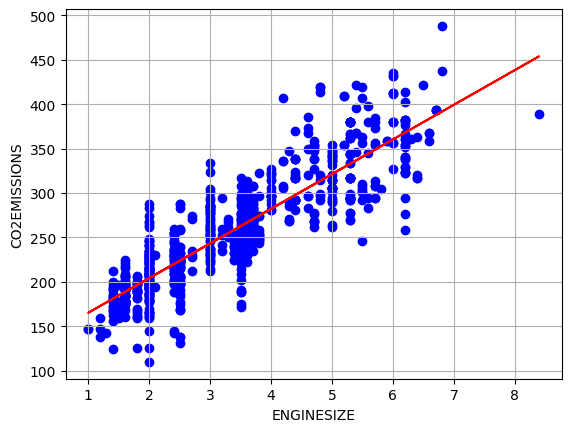

In [10]:
predictCo2 = model.predict(X_test)
print(f"Predict: \n {predictCo2}")

plt.scatter(X_train, Y_train, color='blue')
plt.plot(X_train, model.coef_[0][0] * X_train + model.intercept_[0], 'red')
plt.xlabel('ENGINESIZE')
plt.ylabel('CO2EMISSIONS')
plt.grid()
plt.show()

In [12]:
print("Sum of Squares Error (SSE): %2.f " % np.sum((predictCo2 - Y_test)**2))
print("Mean Square Error (MSE): %.2f" % mean_squared_error(Y_test, predictCo2))
print("Mean Absolute Error (MAE): %.2f" % mean_absolute_error(Y_test, predictCo2))
print("R2-score: %.2f" % r2_score(Y_test , predictCo2) )

Sum of Squares Error (SSE): 210991 
Mean Square Error (MSE): 985.94
Mean Absolute Error (MAE): 24.10
R2-score: 0.76


/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
<ipython-input-12-cc5e6e96258f>:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("Sum of Squares Error (SSE): %2.f " % np.sum((predictCo2 - Y_test)**2))


a) Use Logistic Regression to model one toy problem

- Problema: Drug classification for different kind of pacients

In [13]:
df = pd.read_csv("drug200.csv")

print(df.head())

   Age Sex      BP Cholesterol  Na_to_K   Drug
0   23   F    HIGH        HIGH   25.355  DrugY
1   47   M     LOW        HIGH   13.093  drugC
2   47   M     LOW        HIGH   10.114  drugC
3   28   F  NORMAL        HIGH    7.798  drugX
4   61   F     LOW        HIGH   18.043  DrugY


In [14]:
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['BP'] = le.fit_transform(df['BP'])
df['Cholesterol'] = le.fit_transform(df['Cholesterol'])

print(df.head())

   Age  Sex  BP  Cholesterol  Na_to_K   Drug
0   23    0   0            0   25.355  DrugY
1   47    1   1            0   13.093  drugC
2   47    1   1            0   10.114  drugC
3   28    0   2            0    7.798  drugX
4   61    0   1            0   18.043  DrugY


In [15]:
features = df[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']]
drug = df[['Drug']]

print(features.head())
print(drug.head())

   Age  Sex  BP  Cholesterol  Na_to_K
0   23    0   0            0   25.355
1   47    1   1            0   13.093
2   47    1   1            0   10.114
3   28    0   2            0    7.798
4   61    0   1            0   18.043
    Drug
0  DrugY
1  drugC
2  drugC
3  drugX
4  DrugY


In [16]:
X_train, X_test, Y_train, Y_test = train_test_split(features, drug, test_size=0.2, random_state=42)

print(f"X train: \n {X_train}")
print(f"X test: \n {X_test}")
print(X_train.shape)
print(X_test.shape)

X train: 
      Age  Sex  BP  Cholesterol  Na_to_K
79    32    0   1            1   10.840
197   52    1   2            0    9.894
38    39    0   2            1    9.709
24    33    0   1            0   33.486
122   34    1   2            0   22.456
..   ...  ...  ..          ...      ...
106   22    1   2            0   11.953
14    50    0   2            0   12.703
92    29    0   0            0   29.450
179   67    0   2            0   15.891
102   28    0   1            0   13.127

[160 rows x 5 columns]
X test: 
      Age  Sex  BP  Cholesterol  Na_to_K
95    36    1   1            1   11.424
15    16    0   0            1   15.516
30    18    0   2            1    8.750
158   59    0   1            0   10.444
128   47    1   1            1   33.542
115   51    1   0            0   18.295
69    18    0   0            1   24.276
170   28    0   2            0   12.879
174   42    1   0            1   12.766
45    66    0   2            1    8.107
66    29    1   0            0   12

In [17]:
model = linear_model.LogisticRegression()
model.fit(X_train, Y_train)

print(f"Intercept: {model.intercept_}")
print(f"Coefficient: {model.coef_}")

Intercept: [-2.5975186   1.30397917 -0.38494167  0.53107495  1.14740615]
Coefficient: [[-0.04873276 -0.300527    0.52707309 -0.87420761  0.4895666 ]
 [-0.02882447  0.64475594 -2.35999326  0.31947992  0.07052893]
 [ 0.09039788 -0.5667684  -2.21717178 -0.22432222 -0.23174878]
 [-0.00572471  0.57041288  0.83157076 -1.27633026 -0.03333059]
 [-0.00711594 -0.34787342  3.21852118  2.05538017 -0.29501617]]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
predictDrug = model.predict(X_test)

print(f"Predict: \n {predictDrug}")
print(f"Accuracy: {accuracy_score(Y_test, predictDrug):.2f}")
print(f"Confusion Matrix: \n{confusion_matrix(Y_test, predictDrug)}")


Predict: 
 ['drugX' 'DrugY' 'drugX' 'drugX' 'DrugY' 'DrugY' 'DrugY' 'drugX' 'drugA'
 'drugX' 'drugA' 'drugX' 'DrugY' 'DrugY' 'drugB' 'DrugY' 'drugB' 'drugX'
 'drugX' 'DrugY' 'drugB' 'drugX' 'drugX' 'DrugY' 'DrugY' 'DrugY' 'drugX'
 'drugX' 'DrugY' 'drugX' 'DrugY' 'drugX' 'DrugY' 'DrugY' 'drugA' 'DrugY'
 'drugX' 'DrugY' 'DrugY' 'DrugY']
Accuracy: 0.80
Confusion Matrix: 
[[15  0  0  0  0]
 [ 3  3  0  0  0]
 [ 0  0  3  0  0]
 [ 1  0  0  0  4]
 [ 0  0  0  0 11]]
